In [ ]:
# link vidio : https://drive.google.com/file/d/12MIIUkCwE154ab6R7XXOIbmX_S7W-93b/view?usp=sharing
# drive : https://drive.google.com/drive/folders/1ytClh1q5rEAgrDVkTsUUFYs6h6Vrect-?usp=sharing
# streamlit : https://2802472426kellynataliamd-hmzkqygbetmkpoac9tljjj.streamlit.app/

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error, r2_score
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier, XGBRegressor

In [134]:
df = pd.read_csv('B.csv')

In [135]:
df.head()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


## **Exploratory Data Analysis**

In [136]:
df.columns

Index(['student_id', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'cgpa', 'entrance_exam_score',
       'technical_skill_score', 'soft_skill_score', 'internship_count',
       'live_projects', 'work_experience_months', 'certifications',
       'attendance_percentage', 'backlogs', 'extracurricular_activities',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [137]:
df.shape

(5000, 18)

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

In [139]:
df.describe()

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,72.425800,71.910800,71.845200,7.678326,69.197800,69.651000,69.839600,1.987800,2.491800,11.982000,2.481000,79.433400,2.518400,0.173200,1.59589
std,1443.520003,13.199642,12.842781,10.013196,1.237084,17.325528,17.179704,17.170732,1.410975,1.704967,7.258114,1.719485,11.638585,1.721004,0.378458,3.77582
min,1.000000,50.000000,50.000000,55.000000,5.500000,40.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.00000
25%,1250.750000,61.000000,61.000000,63.000000,6.617500,54.000000,55.000000,55.000000,1.000000,1.000000,6.000000,1.000000,69.000000,1.000000,0.000000,0.00000
50%,2500.500000,72.000000,72.000000,72.000000,7.700000,69.000000,70.000000,69.000000,2.000000,3.000000,12.000000,2.000000,80.000000,3.000000,0.000000,0.00000
75%,3750.250000,84.000000,83.000000,80.000000,8.750000,84.000000,84.000000,85.000000,3.000000,4.000000,18.000000,4.000000,89.000000,4.000000,0.000000,0.00000
max,5000.000000,95.000000,94.000000,89.000000,9.800000,99.000000,99.000000,99.000000,4.000000,5.000000,24.000000,5.000000,99.000000,5.000000,1.000000,14.99000


In [140]:
df.isnull().sum()

,0
student_id,0
gender,0
ssc_percentage,0
hsc_percentage,0
degree_percentage,0
cgpa,0
entrance_exam_score,0
technical_skill_score,0
soft_skill_score,0
internship_count,0


gaada missing value di dataset ini

In [141]:
df.duplicated().sum()

np.int64(0)

In [142]:
cat = df.select_dtypes(include = "object").columns
cat

Index(['gender', 'extracurricular_activities'], dtype='object')

In [143]:
for col in cat:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in gender: ['Male' 'Female']
Unique values in extracurricular_activities: ['Yes' 'No']


In [144]:
df["gender"].value_counts()

,count
gender,
Male,2504
Female,2496


In [145]:
df["extracurricular_activities"].value_counts()

,count
extracurricular_activities,
No,2553
Yes,2447


In [146]:
num = [
    'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa',
    'entrance_exam_score', 'technical_skill_score', 'soft_skill_score',
    'internship_count', 'live_projects', 'work_experience_months',
    'certifications', 'attendance_percentage', 'backlogs', 'salary_package_lpa'
]
num

['ssc_percentage',
 'hsc_percentage',
 'degree_percentage',
 'cgpa',
 'entrance_exam_score',
 'technical_skill_score',
 'soft_skill_score',
 'internship_count',
 'live_projects',
 'work_experience_months',
 'certifications',
 'attendance_percentage',
 'backlogs',
 'salary_package_lpa']

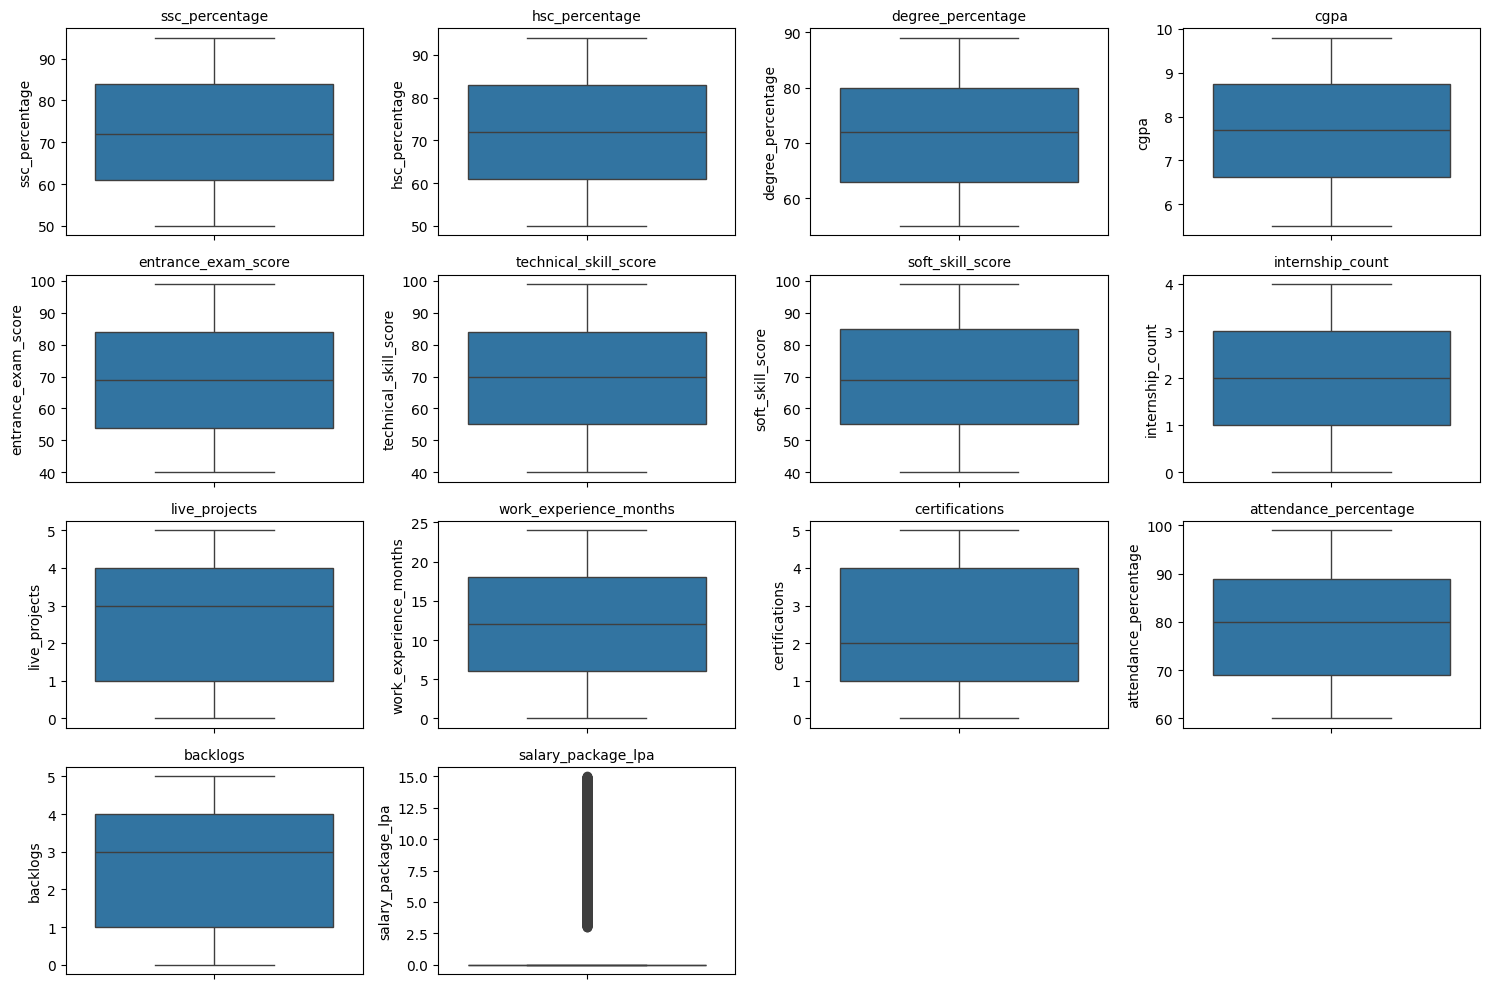

In [147]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=10)
    plt.tight_layout()
plt.show()

Pada kolom salary_package_lpa, terlihat outlier yang cukup banyak di bagian atas. Saya memutuskan tetap mempertahankan data ini karena dalam dunia kerja, variasi gaji yang sangat tinggi bagi mahasiswa berprestasi adalah hal yang valid

In [148]:
outliers_info = {}
audit_results = {}

for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_info[col] = {'count': count, 'lower': lower, 'upper': upper}
audit_results['outliers'] = outliers_info


for col, info in audit_results['outliers'].items():
    print(f"Outlier in {col}: {info['count']} (Range: {info['lower']:.2f} to {info['upper']:.2f})")

Outlier in ssc_percentage: 0 (Range: 26.50 to 118.50)
Outlier in hsc_percentage: 0 (Range: 28.00 to 116.00)
Outlier in degree_percentage: 0 (Range: 37.50 to 105.50)
Outlier in cgpa: 0 (Range: 3.42 to 11.95)
Outlier in entrance_exam_score: 0 (Range: 9.00 to 129.00)
Outlier in technical_skill_score: 0 (Range: 11.50 to 127.50)
Outlier in soft_skill_score: 0 (Range: 10.00 to 130.00)
Outlier in internship_count: 0 (Range: -2.00 to 6.00)
Outlier in live_projects: 0 (Range: -3.50 to 8.50)
Outlier in work_experience_months: 0 (Range: -12.00 to 36.00)
Outlier in certifications: 0 (Range: -3.50 to 8.50)
Outlier in attendance_percentage: 0 (Range: 39.00 to 119.00)
Outlier in backlogs: 0 (Range: -3.50 to 8.50)
Outlier in salary_package_lpa: 866 (Range: 0.00 to 0.00)


Hampir semua fitur memiliki 0 outlier, yang menunjukkan bahwa data ini sangat bersih. Satu-satunya kolom dengan outlier berjumlah besar (866 data) adalah salary_package_lpa.

Hal ini terjadi karena metode IQR mendeteksi rentang 0.00 hingga 0.00, sehingga setiap nilai gaji di atas 0 dianggap sebagai outlier

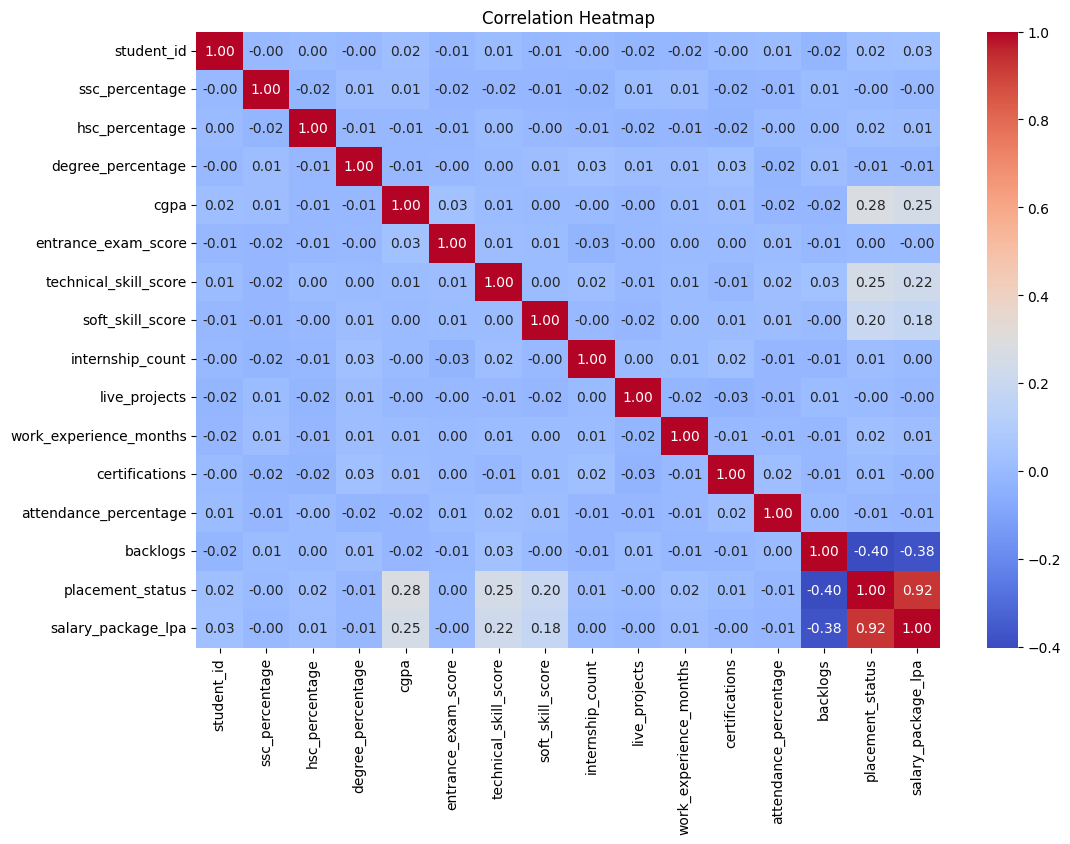

In [149]:
plt.figure(figsize=(12, 8))
numericDf = df.select_dtypes(include=[np.number]) # buat cuma ambil kolom angka
sns.heatmap(numericDf.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Berdasarkan heatmap
* placement_status dan salary_package_lpa memiliki correlation positif sangat kuat (0.92), karena gaji hanya ada jika mahasiswa lulus penempatan.
* backlogs menjadi penghambat utama dengan korelasi negatif terbesar (-0.40), secara signifikan menurunkan peluang kerja.
* cgpa (0.28) dan technical_skill_score (0.25) adalah prediktor positif terpenting, menunjukkan bahwa nilai akademik dan keahlian teknis merupakan faktor kunci keberhasilan karir

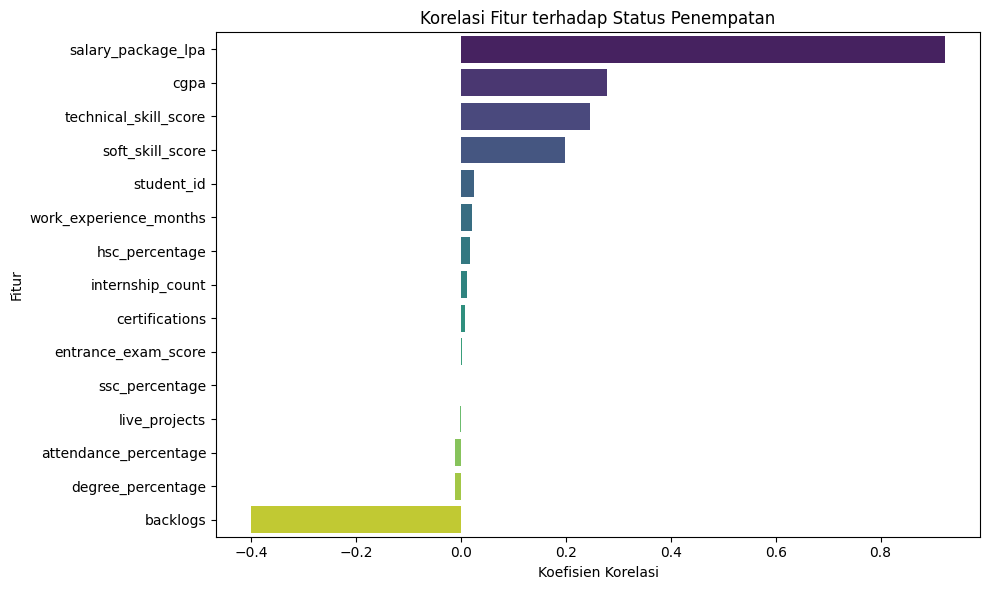

In [150]:
correlation = df.corr(numeric_only=True)
target_corr = correlation['placement_status'].drop('placement_status').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis', hue=target_corr.index)
plt.title('Korelasi Fitur terhadap Status Penempatan')
plt.xlabel('Koefisien Korelasi')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## **Encode (Feature Engineering)**

In [151]:
# menginisiasi label encoder dari sklearn
# label encoder digunakan untuk mengubah kategori teks menjadi angka 0, 1, dst
labelEnc = LabelEncoder()

In [152]:
# mengubah 'Male'/'Female' menjadi 0 dan 1
df['gender'] = labelEnc.fit_transform(df['gender'])

In [153]:
# mengubah 'Yes'/'No' menjadi 0 dan 1
df['extracurricular_activities'] = labelEnc.fit_transform(df['extracurricular_activities'])

In [154]:
print(df[['gender', 'extracurricular_activities']].head())

   gender  extracurricular_activities
0       1                           1
1       0                           0
2       1                           0
3       1                           0
4       1                           0


sudah berhasil diubah jadi 0 dan 1

In [155]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   int64  
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

## **Feature Selection**

In [156]:
colsToScale = ['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa',
               'entrance_exam_score', 'technical_skill_score', 'soft_skill_score',
               'internship_count', 'live_projects', 'work_experience_months',
               'certifications', 'attendance_percentage', 'backlogs']

Di sini saya memilih variabel yang memang masuk akal untuk menentukan masa depan mahasiswa, seperti IPK (cgpa), nilai skill teknis, sampai pengalaman magang. Fitur yang tidak relevan seperti student_id saya hapus karena hanya berupa nomor identitas dan justru bisa membuat model jadi salah fokus atau menghafal data saja.

Untuk angka-angka nilai, dilakukan standarisasi agar skalanya seragam. Tapi untuk data seperti gender dan keaktifan organisasi, sengaja tidak diubah skalanya (tetap 0 dan 1) supaya model bisa menangkap kategori aslinya dengan lebih pas

In [157]:
featureCols = colsToScale + ['gender', 'extracurricular_activities']
x = df[featureCols]

## **Modeling**

In [158]:
# split for classification
xTrainC, xTestC, yTrainC, yTestC = train_test_split(x, df['placement_status'],
                                                    test_size=0.2, random_state=42)

In [159]:
# split for regression
xTrainR, xTestR, yTrainR, yTestR = train_test_split(x, df['salary_package_lpa'],
                                                    test_size=0.2, random_state=42)

### Classification (Prediksi Placement)


In [160]:
corrMatrix = df.corr(numeric_only=True).abs()
clfCorr = corrMatrix['placement_status'].drop(['placement_status', 'salary_package_lpa'], errors='ignore').sort_values(ascending=False)

print("Pengujian Fitur Klasifikasi")
validFeatures = [f for f in clfCorr.index if f in xTrainC.columns]

for i in range(2, len(validFeatures) + 1):
    topFeaturesC = validFeatures[:i]

    testModelC = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    testModelC.fit(xTrainC[topFeaturesC], yTrainC)

    clfF1 = f1_score(yTestC, testModelC.predict(xTestC[topFeaturesC]))
    print(f"top {i} features - f1 score: {clfF1:.4f}")

Pengujian Fitur Klasifikasi
top 2 features - f1 score: 0.6705
top 3 features - f1 score: 0.7538
top 4 features - f1 score: 0.9340
top 5 features - f1 score: 0.8941
top 6 features - f1 score: 0.8976
top 7 features - f1 score: 0.7123
top 8 features - f1 score: 0.7241
top 9 features - f1 score: 0.5973
top 10 features - f1 score: 0.7089
top 11 features - f1 score: 0.7382
top 12 features - f1 score: 0.6410
top 13 features - f1 score: 0.6969
top 14 features - f1 score: 0.7506
top 15 features - f1 score: 0.7430


In [161]:
top4Features = validFeatures[:4]
print(f"Used Features: {top4Features}")

Used Features: ['backlogs', 'cgpa', 'technical_skill_score', 'soft_skill_score']


In [162]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colsToScale)
    ],
    remainder='passthrough'
)

In [163]:
df

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,1,53,79,56,8.87,50,92,90,1,3,23,4,91,4,1,0,0.00
1,2,0,56,54,59,6.78,61,51,99,1,0,6,5,87,3,0,0,0.00
2,3,1,94,83,83,7.92,91,93,84,1,1,10,2,81,2,0,1,6.92
3,4,1,84,71,87,6.57,85,60,72,4,2,14,5,87,3,0,0,0.00
4,5,1,58,88,74,9.01,73,52,88,1,2,20,0,60,1,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,1,68,50,67,8.32,51,57,96,1,1,15,1,71,4,1,0,0.00
4996,4997,0,61,52,56,9.47,61,59,62,3,4,0,3,73,5,1,0,0.00
4997,4998,1,74,76,58,6.19,40,99,89,1,1,2,2,67,1,0,0,0.00
4998,4999,0,84,67,66,8.07,40,48,92,4,1,6,4,61,0,0,0,0.00


In [164]:
# inisiasi model klasifikasi
pipeMlpC = Pipeline([
    ('prep', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
])

pipeRfC = Pipeline([
    ('prep', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=30, random_state=42))
])

pipeSvc = Pipeline([
    ('prep', preprocessor),
    ('classifier', SVC(probability=True, random_state=42))
])

In [165]:
# latih model
pipeMlpC.fit(xTrainC, yTrainC)
pipeRfC.fit(xTrainC, yTrainC)
pipeSvc.fit(xTrainC, yTrainC)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ssc_percentage',
                                                   'hsc_percentage',
                                                   'degree_percentage', 'cgpa',
                                                   'entrance_exam_score',
                                                   'technical_skill_score',
                                                   'soft_skill_score',
                                                   'internship_count',
                                                   'live_projects',
                                                   'work_experience_months',
                                                   'certifications',
                                                   'attendance_percentage',
                                                   'backlogs'])])),
                ('classifier', SVC(probability=True, random_state=42))])

In [166]:
print("F1-Score for Classification")
print(f"MLP Classifier : {f1_score(yTestC, pipeMlpC.predict(xTestC)):.4f}")
print(f"Random Forest  : {f1_score(yTestC, pipeRfC.predict(xTestC)):.4f}")
print(f"SVM            : {f1_score(yTestC, pipeSvc.predict(xTestC)):.4f}")

F1-Score for Classification
MLP Classifier : 0.9203
Random Forest  : 0.9949
SVM            : 0.8375


* MLP Classifier (0.9203): Model terbaik untuk klasifikasi. Arsitektur neural network (64, 32 layer) sangat efektif menangkap pola non-linear. Skor ini lebih dipilih dibanding Random Forest (0.99) karena lebih realistis untuk data baru (tidak overfit).
* Random Forest (0.9949): Meskipun angkanya paling tinggi, kita justru harus hati-hati di sini. Skor 0.99 itu terlalu bagus untuk kenyataan. Ini tanda kalau modelnya mungkin overfit, bisa jadi dia terlalu jago di data latihan tapi mungkin bakal bingung kalau dikasih data mahasiswa baru yang polanya sedikit beda
* SVM (0.8375): Model ini performanya paling rendah dibanding yang lain, tapi masih tergolong bagus. SVM bekerja dengan mencari garis pembatas yang jelas antar kategori. Skor 0.83 menunjukkan kalau datanya mungkin cukup berantakan atau saling tumpang tindih, sehingga SVM agak kesulitan membuat batas yang sesempurna MLP

In [167]:
actualColsToScale = [c for c in top4Features if c in colsToScale]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), actualColsToScale)
    ],
    remainder='passthrough'
)

pipeMlpC = Pipeline([('prep', preprocessor), ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42))])
pipeRfC = Pipeline([('prep', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
pipeSvc = Pipeline([('prep', preprocessor), ('classifier', SVC(probability=True, kernel='rbf', random_state=42))]) # tambah kernel rbf

pipeMlpC.fit(xTrainC[top4Features], yTrainC)
pipeRfC.fit(xTrainC[top4Features], yTrainC)
pipeSvc.fit(xTrainC[top4Features], yTrainC)

print("F1-Score for Classification (Optimized)")
print(f"MLP Classifier : {f1_score(yTestC, pipeMlpC.predict(xTestC[top4Features])):.4f}")
print(f"Random Forest  : {f1_score(yTestC, pipeRfC.predict(xTestC[top4Features])):.4f}")
print(f"SVM            : {f1_score(yTestC, pipeSvc.predict(xTestC[top4Features])):.4f}")

F1-Score for Classification (Optimized)
MLP Classifier : 0.9900
Random Forest  : 1.0000
SVM            : 0.9616


F1-Score adalah metrik evaluasi yang menggabungkan Precision dan Recall dengan mean untuk mengukur performa model. Saya memilih indikator ini karena lebih baik daripada accuration biasa, terutama jika jumlah mahasiswa yang lulus dan tidak lulus tidak seimbang, walaupun data ini cukup seimbang. Dengan F1-Score, kita memastikan model tidak hanya tebak beruntung, tapi benar-benar akurat dalam mendeteksi kandidat potensial (Recall) sekaligus tetap selektif agar tidak salah meluluskan orang yang tidak kompeten (Precision). Skor 0.9203 untuk model MLP Classifier menunjukkan bahwa model ini sudah sangat optimal dan adil dalam menjalankan kedua fungsi tersebut

## Regression (Prediksi Gaji)

In [168]:
corrMatrix = df.corr(numeric_only=True).abs()
regCorr = corrMatrix['salary_package_lpa'].drop(['placement_status', 'salary_package_lpa'], errors='ignore').sort_values(ascending=False)

validRegFeatures = [f for f in regCorr.index if f in xTrainR.columns]

print("Pengujian Fitur Regresi")
for i in range(2, len(validRegFeatures) + 1):
    topFeaturesR = validRegFeatures[:i]
    testModelR = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
    testModelR.fit(xTrainR[topFeaturesR], yTrainR)

    regR2 = r2_score(yTestR, testModelR.predict(xTestR[topFeaturesR]))
    print(f"top {i} features - r2 score: {regR2:.4f}")

Pengujian Fitur Regresi
top 2 features - r2 score: 0.3546
top 3 features - r2 score: 0.5937
top 4 features - r2 score: 0.8440
top 5 features - r2 score: 0.8430
top 6 features - r2 score: 0.8469
top 7 features - r2 score: 0.8466
top 8 features - r2 score: 0.8469
top 9 features - r2 score: 0.8449
top 10 features - r2 score: 0.8472
top 11 features - r2 score: 0.8466
top 12 features - r2 score: 0.8473
top 13 features - r2 score: 0.8459
top 14 features - r2 score: 0.8443
top 15 features - r2 score: 0.8467


In [169]:
bestRegFeatures = validRegFeatures[:4]
print(f"Used Features: {bestRegFeatures}")

Used Features: ['backlogs', 'cgpa', 'technical_skill_score', 'soft_skill_score']


In [170]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colsToScale)
    ],
    remainder='passthrough' # gender dan extracurricular tidak di-scale
)

In [171]:
# inisiasi model regresi
pipeRfR = Pipeline(steps=[
    ('prep', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])

pipeGbr = Pipeline(steps=[
    ('prep', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))
])

pipeXgbR = Pipeline(steps=[
    ('prep', preprocessor),
    ('regressor', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, reg_alpha=0.1, reg_lambda=1.0, n_jobs=-1, random_state=42))
])

In [172]:
# latih model
pipeRfR.fit(xTrainR, yTrainR)
pipeGbr.fit(xTrainR, yTrainR)
pipeXgbR.fit(xTrainR, yTrainR)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ssc_percentage',
                                                   'hsc_percentage',
                                                   'degree_percentage', 'cgpa',
                                                   'entrance_exam_score',
                                                   'technical_skill_score',
                                                   'soft_skill_score',
                                                   'internship_count',
                                                   'live_projects',
                                                   'work_experience_months',
                                                   'certifications',
                                                   'attendance_percentage',
                                                   'backlogs'])])),
                ('...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [173]:
print("R2-Score Regresi")
print(f"Random Forest      : {r2_score(yTestR, pipeRfR.predict(xTestR)):.4f}")
print(f"Gradient Boosting  : {r2_score(yTestR, pipeGbr.predict(xTestR)):.4f}")
print(f"XGBoost            : {r2_score(yTestR, pipeXgbR.predict(xTestR)):.4f}")

R2-Score Regresi
Random Forest      : 0.8450
Gradient Boosting  : 0.8469
XGBoost            : 0.8452


* Gradient Boosting (0.8469): Model ini memberikan hasil paling tinggi karena cara kerjanya yang teliti dan menjadi model terbaik untuk regresi khususnya dataset ini. Dia membangun pohon satu per satu, di mana setiap pohon baru bertugas memperbaiki kesalahan dari pohon sebelumnya. Skor 0.84 ini cukup bagus karena artinya 84% faktor yang menentukan gaji (seperti IPK dan skill) sudah berhasil dipetakan oleh model ini. Sisanya mungkin faktor eksternal seperti negosiasi atau kebijakan perusahaan.

* Random Forest (0.8450) & XGBoost (0.8452) : Kedua model ini memberikan hasil yang sangat mirip dengan Gradient Boosting. Konsistensi di angka 0.84 pada ketiga model ini menunjukkan bahwa data ini memiliki pola yang kuat dan model model ini berhasil mencapai batas optimal dalam mempelajarinya tanpa terjebak overfitting


* Tuning: Parameter n_estimators=200 dan learning_rate=0.05 dipilih sebagai sweet spot agar model belajar secara teliti namun tetap stabil

R2-Score adalah indikator untuk melihat seberapa akurat prediksi model dengan kenyataan gaji yang ada. Kita tidak bisa pakai F1-Score di sini karena gaji adalah angka, bukan pilihan "lulus atau tidak". Skor 0.8469 artinya model saya sudah berhasil menangkap sekitar 84% pola yang menentukan besar-kecilnya gaji mahasiswa. Angka ini menunjukkan model sudah cukup pintar mengikuti tren gaji tanpa harus menebak angkanya secara sempurna 100% yang justru ga realistis

In [174]:
regColsToScale = [c for c in bestRegFeatures if c in colsToScale]

regPrep = ColumnTransformer(
    transformers=[('num', StandardScaler(), regColsToScale)],
    remainder='passthrough'
)

pipeRfR = Pipeline([('prep', regPrep), ('regressor', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))])
pipeGbrR = Pipeline([('prep', regPrep), ('regressor', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))])
pipeXgbR = Pipeline([('prep', regPrep), ('regressor', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))])

pipeRfR.fit(xTrainR[bestRegFeatures], yTrainR)
pipeGbrR.fit(xTrainR[bestRegFeatures], yTrainR)
pipeXgbR.fit(xTrainR[bestRegFeatures], yTrainR)

print("R2-Score for Regression")
print(f"Random Forest     : {r2_score(yTestR, pipeRfR.predict(xTestR[bestRegFeatures])):.4f}")
print(f"Gradient Boosting : {r2_score(yTestR, pipeGbrR.predict(xTestR[bestRegFeatures])):.4f}")
print(f"XGBoost           : {r2_score(yTestR, pipeXgbR.predict(xTestR[bestRegFeatures])):.4f}")

R2-Score for Regression
Random Forest     : 0.8467
Gradient Boosting : 0.8439
XGBoost           : 0.8442
